### Przygotowanie danych i wstępne przetwarzanie

In [ ]:
import pandas as pd
import numpy as np
import glob

In [ ]:
files = glob.glob('/limu-bert-data/*.csv')

In [ ]:
print(files)

['/limu-bert-data/squats_20260608_151121.csv', '/limu-bert-data/sitting_20260608_175521.csv', '/limu-bert-data/walking_20260608_171650.csv', '/limu-bert-data/standing_20260608_174337.csv', '/limu-bert-data/squats_20260608_174031.csv', '/limu-bert-data/jumping_jacks_20260608_151853.csv', '/limu-bert-data/walking_20260608_171218.csv', '/limu-bert-data/pushups_20260607_212824.csv', '/limu-bert-data/pushups_20260608_140122.csv', '/limu-bert-data/walking_20260608_154216.csv', '/limu-bert-data/walking_20260608_172124.csv', '/limu-bert-data/standing_20260608_174723.csv', '/limu-bert-data/sitting_20260608_175249.csv', '/limu-bert-data/sitting_20260608_175754.csv', '/limu-bert-data/jumping_jacks_20260608_180504.csv', '/limu-bert-data/pushups_20260608_152751.csv', '/limu-bert-data/jumping_jacks_20260607_215916.csv', '/limu-bert-data/pushups_20260608_153126.csv', '/limu-bert-data/squats_20260608_173358.csv', '/limu-bert-data/jumping_jacks_20260607_215611.csv', '/limu-bert-data/standing_20260608_1

Dane były zbierane przez sensor z częstotliwością 50Hz, pretrenowane wagi modelu LIMU-BERT były uczone na oknach 120 próbek, zbieranych z częstotliwościa 20Hz.

Przeprowadzenie resemplingu danych do 20Hz:

In [ ]:
from scipy.signal import resample

In [ ]:
def resample_to_20Hz(df):
  num_samples_20Hz = int(len(df) * (20 / 50))

  raw_data = df[['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']].values
  resampled_data = resample(raw_data, num_samples_20Hz)

  label = df['label'].iloc[0]

  return resampled_data, label

In [ ]:
import matplotlib.pyplot as plt

Dane przed resamplingiem i podziałem na okna:

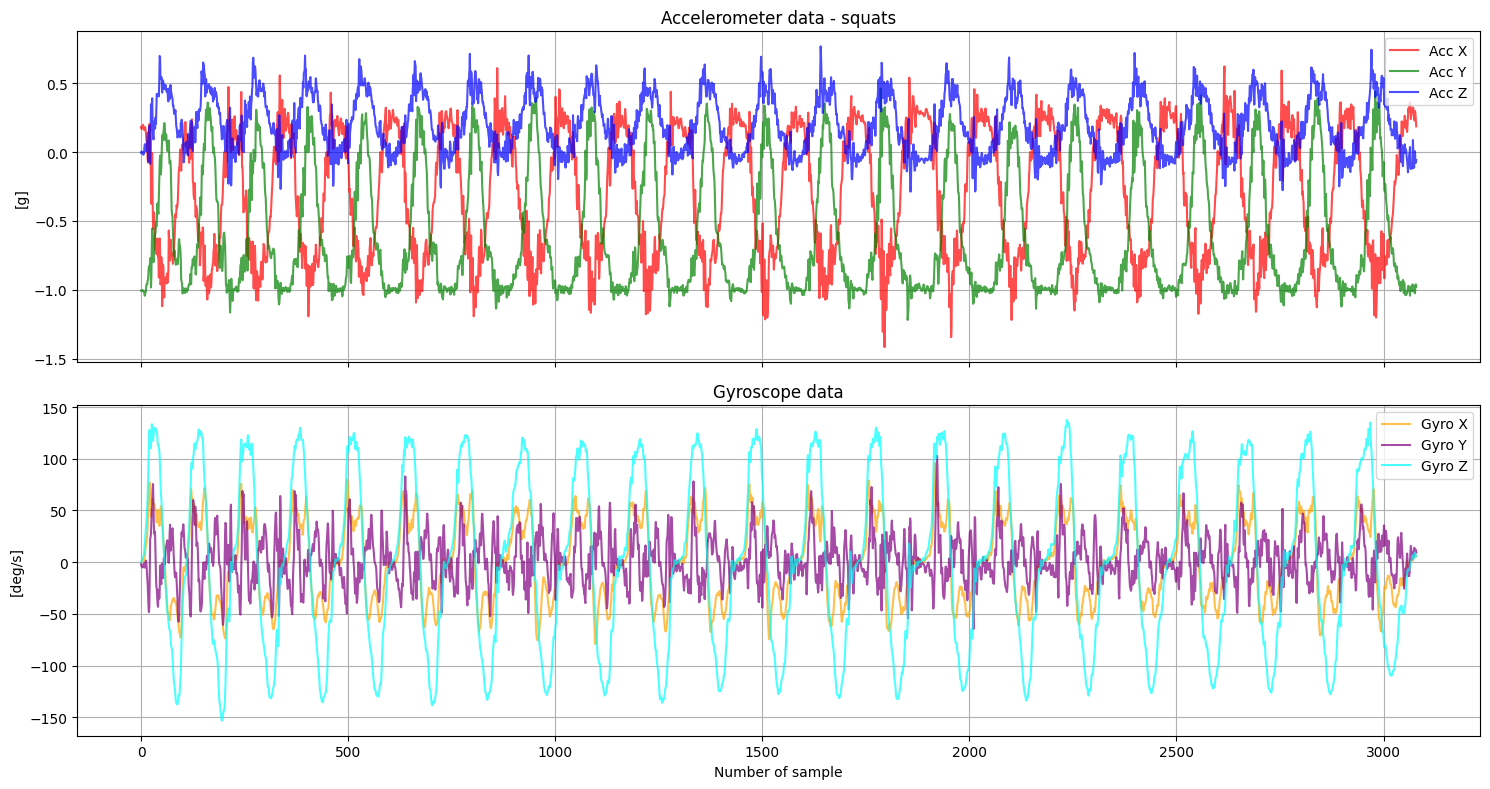

In [ ]:
df_sq = pd.read_csv(files[0])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

ax1.plot(df_sq['acc_x'], label='Acc X', color='red', alpha=0.7)
ax1.plot(df_sq['acc_y'], label='Acc Y', color='green', alpha=0.7)
ax1.plot(df_sq['acc_z'], label='Acc Z', color='blue', alpha=0.7)
ax1.set_title('Accelerometer data - ' + df_sq['label'].iloc[0])
ax1.set_ylabel('[g]')
ax1.legend()
ax1.grid(True)

ax2.plot(df_sq['gyro_x'], label='Gyro X', color='orange', alpha=0.7)
ax2.plot(df_sq['gyro_y'], label='Gyro Y', color='purple', alpha=0.7)
ax2.plot(df_sq['gyro_z'], label='Gyro Z', color='cyan', alpha=0.7)
ax2.set_title('Gyroscope data')
ax2.set_ylabel('[deg/s]')
ax2.set_xlabel('Number of sample')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

Przetworzenie danych, resamplig do 20Hz i podział na okna

In [ ]:
X, y, groups = [], [], []

window_size = 120
step = 60

In [ ]:
for file_idx, f in enumerate(files):
  df = pd.read_csv(f)
  data, label = resample_to_20Hz(df)

  for i in range(0, len(data) - window_size + 1, step):
    window = data[i:i+window_size]
    X.append(window)
    y.append(label)
    groups.append(file_idx)

X = np.array(X)
y = np.array(y)
groups = np.array(groups)

print(X.shape, y.shape, groups.shape)

(744, 120, 6) (744,) (744,)


Wyznaczenie całkowitej wielkości danych, po podziale na okna

In [ ]:
print(X.shape, y.shape)

(744, 120, 6) (744,)


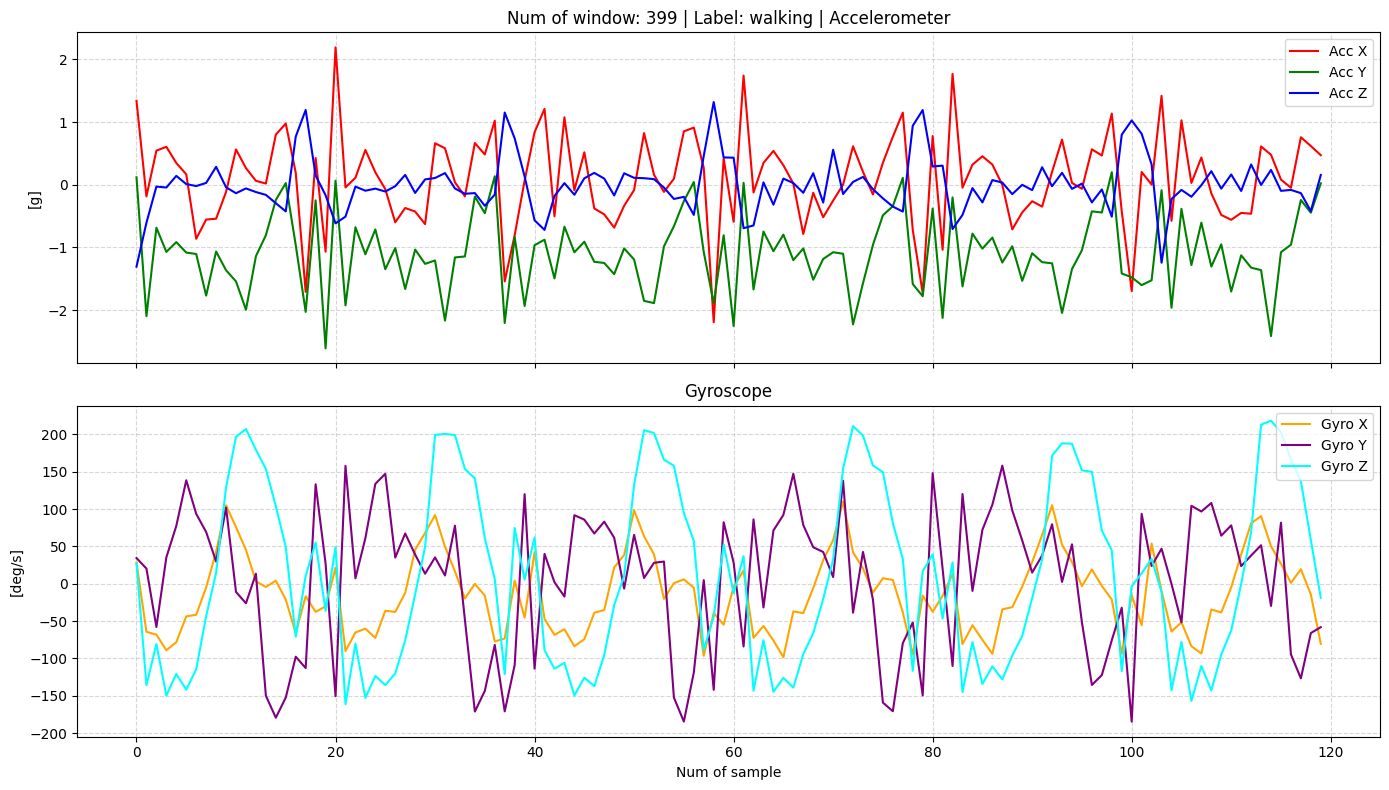

In [ ]:
import random

random_indeks = random.randint(0, len(X) - 1)

random_window = X[random_indeks]
window_label = y[random_indeks]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(random_window[:, 0], label='Acc X', color='red')
ax1.plot(random_window[:, 1], label='Acc Y', color='green')
ax1.plot(random_window[:, 2], label='Acc Z', color='blue')
ax1.set_title(f"Num of window: {random_indeks} | Label: {window_label} | Accelerometer")
ax1.set_ylabel("[g]")
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.plot(random_window[:, 3], label='Gyro X', color='orange')
ax2.plot(random_window[:, 4], label='Gyro Y', color='purple')
ax2.plot(random_window[:, 5], label='Gyro Z', color='cyan')
ax2.set_title("Gyroscope")
ax2.set_xlabel("Num of sample")
ax2.set_ylabel("[deg/s]")
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Przed rozpoczaczeciem procesu normalizacji sprawdzone zostaje wystepowanie outlinerow ktore moga potencjalnie psuc proces noralizacji

/tmp/ipykernel_913/2182571510.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([X[y == label, :, i].flatten()
/tmp/ipykernel_913/2182571510.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([X[y == label, :, i].flatten()
/tmp/ipykernel_913/2182571510.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([X[y == label, :, i].flatten()
/tmp/ipykernel_913/2182571510.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([X[y == label, :, i].flatten()
/tmp

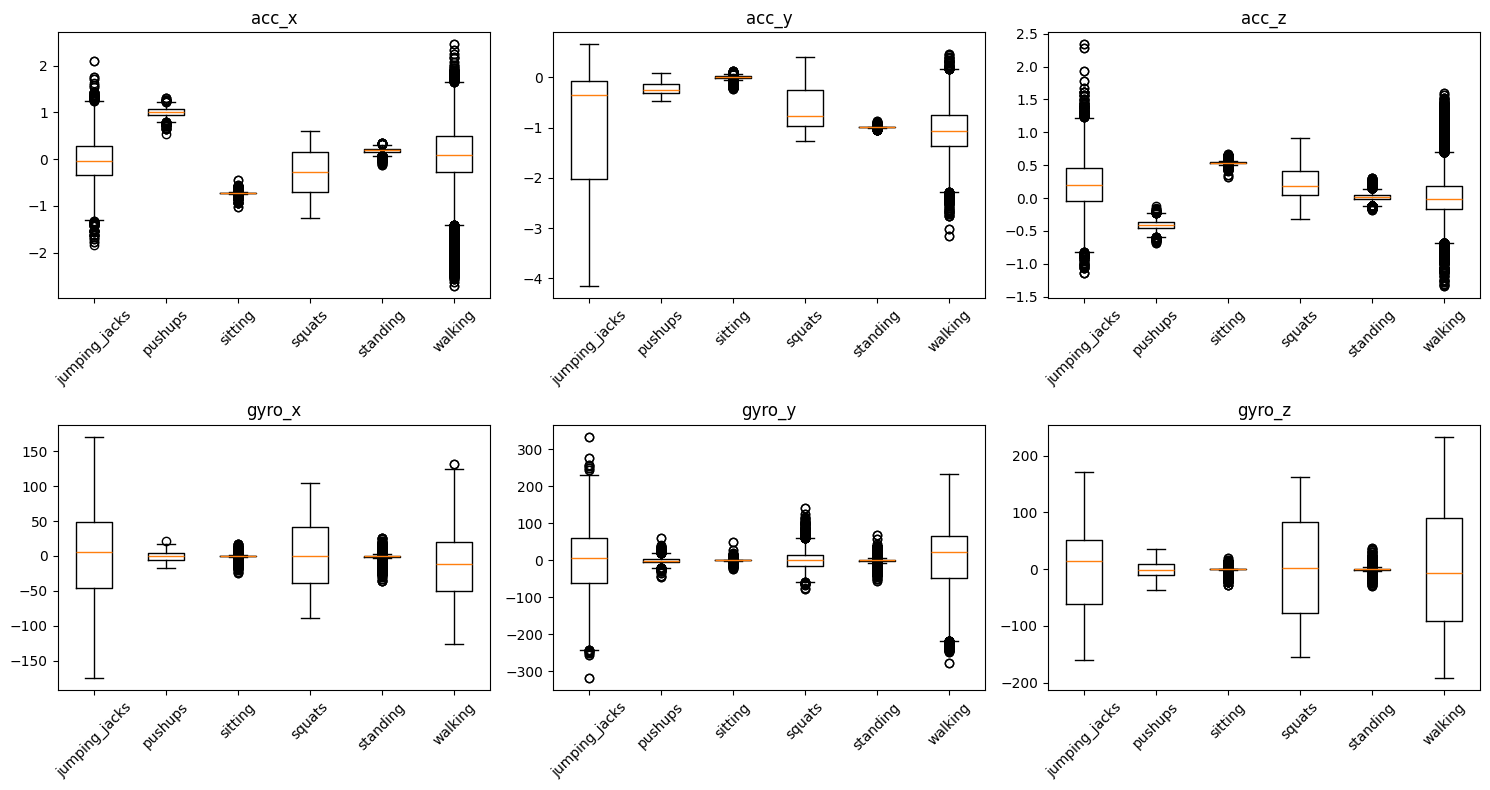

Gyro stats:
gyro_x: min=-175.09, max=171.07, std=40.09, p1%=-97.41, p99%=97.50
gyro_y: min=-318.61, max=334.76, std=61.13, p1%=-178.49, p99%=144.11
gyro_z: min=-192.17, max=233.37, std=78.65, p1%=-138.85, p99%=199.46


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
feature_names = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']

for i, name in enumerate(feature_names):
    ax = axes[i // 3, i % 3]
    ax.boxplot([X[y == label, :, i].flatten()
                for label in np.unique(y)],
               labels=np.unique(y))
    ax.set_title(name)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('Gyro stats:')
for i, name in enumerate(['gyro_x', 'gyro_y', 'gyro_z']):
    vals = X[:, :, i+3].flatten()
    print(f'{name}: min={vals.min():.2f}, max={vals.max():.2f}, '
          f'std={vals.std():.2f}, '
          f'p1%={np.percentile(vals, 1):.2f}, '
          f'p99%={np.percentile(vals, 99):.2f}')

Powyzej widac wartosci odstajace np. +- 300 deg/s dla gyro_z które psują normalizacje.

Dodajemy clipping: do +-3g dla akcelerometru i +-120 deg/s dla żyroskopu

In [ ]:
X[:, :, :3] = np.clip(X[:, :, :3], -3, 3)
X[:, :, 3:] = np.clip(X[:, :, 3:], -120, 120)

print('After clipping:')
for i, name in enumerate(['acc_x', 'acc_y', 'acc_z']):
    vals = X[:, :, i].flatten()
    print(f'{name}: min={vals.min():.2f}, max={vals.max():.2f}, std={vals.std():.2f}')

for i, name in enumerate(['gyro_x', 'gyro_y', 'gyro_z']):
    vals = X[:, :, i+3].flatten()
    print(f'{name}: min={vals.min():.2f}, max={vals.max():.2f}, std={vals.std():.2f}')

After clipping:
acc_x: min=-2.70, max=2.46, std=0.62
acc_y: min=-3.00, max=0.66, std=0.64
acc_z: min=-1.33, max=2.34, std=0.37
gyro_x: min=-120.00, max=120.00, std=39.81
gyro_y: min=-120.00, max=120.00, std=54.73
gyro_z: min=-120.00, max=120.00, std=67.81


### Przygotowanie danych do przeprowadzenia treningu

Enkodowanie etykiet tekstowych na liczby

In [ ]:
from sklearn.preprocessing import LabelEncoder
import pickle

In [ ]:
le = LabelEncoder()
y_enc = le.fit_transform(y)
print("Kolejność klas:", le.classes_)

Kolejność klas: ['jumping_jacks' 'pushups' 'sitting' 'squats' 'standing' 'walking']


Encoder zostaje zapisany, zastosowany zostanie podczas wykrywania aktywności w czesie rzeczywistym

In [ ]:
with open('/content/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

Dane zostają podzielone na zbiór treningowy i testowy w proporcjach: 80 do 20

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y_enc, groups=groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y_enc[train_idx], y_enc[test_idx]
groups_train, groups_test = groups[train_idx], groups[test_idx]

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (624, 120, 6), X_test: (120, 120, 6)


Do zbioru treningowego zosają dodane sztucznie zmodyfikowane okna zawierające lekki szum oraz lekkie przeskalowanie.

In [ ]:
def augment_data(X_data, y_data):
    X_aug, y_aug = [], []
    for window, label in zip(X_data, y_data):
        X_aug.append(window)
        y_aug.append(label)

        noise = np.random.normal(0, 0.015, window.shape)
        scale = np.random.uniform(0.85, 1.15)
        augmented_window = (window + noise) * scale

        X_aug.append(augmented_window)
        y_aug.append(label)

    return np.array(X_aug), np.array(y_aug)

Dane zostają powielone dwukrotnie

In [ ]:
X_train_aug, y_train_aug = augment_data(X_train, y_train)

print(f"X_train_aug: {X_train_aug.shape}")

X_train_aug: (1248, 120, 6)


Przeprowadzenie procesu normalizacji

Parametry normalizacji sa wyliczane wyłącznie dla zbioru treningowego

In [ ]:
mean = X_train.mean(axis=(0, 1))
std = X_train.std(axis=(0, 1))
std[std == 0] = 1e-8

# 2. Zapis parametrów
import os
os.makedirs('/content/limu_export', exist_ok=True)
np.save('/content/mean.npy', mean)
np.save('/content/std.npy', std)
np.save('/content/limu_export/mean.npy', mean)
np.save('/content/limu_export/std.npy', std)

# 3. Normalizacja
X_train_norm = (X_train - mean) / std
X_test_norm = (X_test - mean) / std

Dane treningowe i testowe ponownie są łączone w jedna macierz, skrypt LIMU-BERT ponownie je podzieli automatycznie

In [ ]:
X_final = np.concatenate([X_train_norm, X_test_norm], axis=0)
y_final = np.concatenate([y_train, y_test], axis=0)
groups_final = np.concatenate([groups_train, groups_test], axis=0)

In [ ]:
print(f"y_final shape: {y_final.shape}, unikalne: {np.unique(y_final)}")

y_final shape: (744,), unikalne: [0 1 2 3 4 5]


### Zastosowanie modelu LIMU-BERT

Przygotowanie srodowiska i klonowanie zależnośći

In [ ]:
%cd /content
!rm -rf LIMU-BERT-Public

!git clone https://github.com/dapowan/LIMU-BERT-Public
%cd LIMU-BERT-Public
!rm -f requirements.txt

!pip install fastdtw

/content
Cloning into 'LIMU-BERT-Public'...
remote: Enumerating objects: 154, done.
remote: Counting objects: 100% (67/67), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 154 (delta 48), reused 34 (delta 34), pack-reused 87 (from 1)
Receiving objects: 100% (154/154), 107.45 MiB | 21.81 MiB/s, done.
Resolving deltas: 100% (68/68), done.
Updating files: 100% (46/46), done.
/content/LIMU-BERT-Public


In [ ]:
utils_path = 'utils.py'
classifier_path = 'classifier.py'

with open(utils_path, 'r') as f:
    utils_src = f.read()

with open(classifier_path, 'r') as f:
    classifier_src = f.read()

old_partition = '''def partition_and_reshape(data, labels, label_index=0, training_rate=0.8, vali_rate=0.1, change_shape=True
                          , merge=0, merge_mode='all', shuffle=True):
    arr = np.arange(data.shape[0])
    if shuffle:
        np.random.shuffle(arr)
    data = data[arr]
    labels = labels[arr]
    train_num = int(data.shape[0] * training_rate)
    vali_num = int(data.shape[0] * vali_rate)
    data_train = data[:train_num, ...]
    data_vali = data[train_num:train_num+vali_num, ...]
    data_test = data[train_num+vali_num:, ...]'''

new_partition = '''def partition_and_reshape(data, labels, label_index=0, training_rate=0.8, vali_rate=0.1, change_shape=True
                          , merge=0, merge_mode='all', shuffle=True, groups=None):
    n = data.shape[0]
    if groups is not None:
        from sklearn.model_selection import GroupShuffleSplit
        gss1 = GroupShuffleSplit(n_splits=1, train_size=training_rate, random_state=0)
        train_idx, rest_idx = next(gss1.split(np.arange(n), groups=groups))
        rest_groups = groups[rest_idx]
        vali_share = vali_rate / (1 - training_rate)
        if len(np.unique(rest_groups)) > 1 and 0 < vali_share < 1:
            gss2 = GroupShuffleSplit(n_splits=1, train_size=vali_share, random_state=0)
            vali_idx_rel, test_idx_rel = next(gss2.split(rest_idx, groups=rest_groups))
        else:
            vali_idx_rel, test_idx_rel = np.array([], dtype=int), np.arange(len(rest_idx))
        vali_idx = rest_idx[vali_idx_rel]
        test_idx = rest_idx[test_idx_rel]
        arr = np.concatenate([train_idx, vali_idx, test_idx])
        train_num = len(train_idx)
        vali_num = len(vali_idx)
    else:
        arr = np.arange(n)
        if shuffle:
            np.random.shuffle(arr)
        train_num = int(n * training_rate)
        vali_num = int(n * vali_rate)
    data = data[arr]
    labels = labels[arr]
    data_train = data[:train_num, ...]
    data_vali = data[train_num:train_num+vali_num, ...]
    data_test = data[train_num+vali_num:, ...]'''

assert utils_src.count(old_partition) == 1, "Nie znaleziono dokładnego fragmentu partition_and_reshape — sprawdź wersję repo!"
utils_src = utils_src.replace(old_partition, new_partition)

old_prepare = '''def prepare_classifier_dataset(data, labels, label_index=0, training_rate=0.8, label_rate=1.0, change_shape=True
                               , merge=0, merge_mode='all', seed=None, balance=False):

    set_seeds(seed)
    data_train, label_train, data_vali, label_vali, data_test, label_test \\
        = partition_and_reshape(data, labels, label_index=label_index, training_rate=training_rate, vali_rate=0.1
                                , change_shape=change_shape, merge=merge, merge_mode=merge_mode)'''

new_prepare = '''def prepare_classifier_dataset(data, labels, label_index=0, training_rate=0.8, label_rate=1.0, change_shape=True
                               , merge=0, merge_mode='all', seed=None, balance=False, groups=None):

    set_seeds(seed)
    data_train, label_train, data_vali, label_vali, data_test, label_test \\
        = partition_and_reshape(data, labels, label_index=label_index, training_rate=training_rate, vali_rate=0.1
                                , change_shape=change_shape, merge=merge, merge_mode=merge_mode, groups=groups)'''

assert utils_src.count(old_prepare) == 1, "Nie znaleziono dokładnego fragmentu prepare_classifier_dataset — sprawdź wersję repo!"
utils_src = utils_src.replace(old_prepare, new_prepare)

with open(utils_path, 'w') as f:
    f.write(utils_src)

old_classify_sig = '''def classify_embeddings(args, data, labels, label_index, training_rate, label_rate, balance=False, method=None):
    train_cfg, model_cfg, dataset_cfg = load_classifier_config(args)
    label_names, label_num = load_dataset_label_names(dataset_cfg, label_index)
    data_train, label_train, data_vali, label_vali, data_test, label_test \\
        = prepare_classifier_dataset(data, labels, label_index=label_index, training_rate=training_rate
                                     , label_rate=label_rate, merge=model_cfg.seq_len, seed=train_cfg.seed
                                     , balance=balance)'''

new_classify_sig = '''def classify_embeddings(args, data, labels, label_index, training_rate, label_rate, balance=False, method=None, groups=None):
    train_cfg, model_cfg, dataset_cfg = load_classifier_config(args)
    label_names, label_num = load_dataset_label_names(dataset_cfg, label_index)
    data_train, label_train, data_vali, label_vali, data_test, label_test \\
        = prepare_classifier_dataset(data, labels, label_index=label_index, training_rate=training_rate
                                     , label_rate=label_rate, merge=model_cfg.seq_len, seed=train_cfg.seed
                                     , balance=balance, groups=groups)'''

assert classifier_src.count(old_classify_sig) == 1, "Nie znaleziono classify_embeddings — sprawdź wersję repo!"
classifier_src = classifier_src.replace(old_classify_sig, new_classify_sig)

old_main = '''    embedding, labels = load_embedding_label(args.model_file, args.dataset, args.dataset_version)
    label_test, label_estimate_test = classify_embeddings(args, embedding, labels, args.label_index,
                                                          training_rate, label_rate, balance=balance, method=method)'''

new_main = '''    embedding, labels = load_embedding_label(args.model_file, args.dataset, args.dataset_version)
    groups_path = os.path.join('dataset', args.dataset, 'groups_' + args.dataset_version + '.npy')
    groups = np.load(groups_path) if os.path.exists(groups_path) else None
    if groups is None:
        print("UWAGA: nie znaleziono groups_*.npy — split losowy po oknie, bez grupowania po sesji!")
    label_test, label_estimate_test = classify_embeddings(args, embedding, labels, args.label_index,
                                                          training_rate, label_rate, balance=balance, method=method, groups=groups)'''

assert classifier_src.count(old_main) == 1, "Nie znaleziono bloku __main__ — sprawdź wersję repo!"
classifier_src = classifier_src.replace(old_main, new_main)

if 'import os' not in classifier_src.splitlines()[0:15]:
    classifier_src = classifier_src.replace('import argparse\n', 'import argparse\nimport os\n', 1)

with open(classifier_path, 'w') as f:
    f.write(classifier_src)

Dane do treningu zapisywane są w nowo utworzonym folderze

In [ ]:
import os

os.makedirs('/content/LIMU-BERT-Public/dataset/motion', exist_ok=True)
np.save('/content/LIMU-BERT-Public/dataset/motion/data_20_120.npy', X_final)

y_3d = np.repeat(y_final[:, np.newaxis, np.newaxis], 120, axis=1)
np.save('/content/LIMU-BERT-Public/dataset/motion/label_20_120.npy', y_3d)

np.save('/content/LIMU-BERT-Public/dataset/motion/groups_20_120.npy', groups_final)
print(f'y_3d shape: {y_3d.shape}')

y_3d shape: (744, 120, 1)


Uruchamianie procesu uczenia

In [ ]:
# 1. Self-supervised pre-training (Model uczy się fizyki sygnału)
!python pretrain.py v1 motion 20_120

2026-07-23 12:11:44.041244: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Train Size: 595, Vali Size: 74, Test Size: 75
cuda:0 (1 GPUs)
Epoch 1/3200 : Average Loss 0.5625. Test Loss 0.4816
Epoch 2/3200 : Average Loss 0.4487. Test Loss 0.4784
Epoch 3/3200 : Average Loss 0.4419. Test Loss 0.4467
Epoch 4/3200 : Average Loss 0.4365. Test Loss 0.4566
Epoch 5/3200 : Average Loss 0.4383. Test Loss 0.4479
Epoch 6/3200 : Average Loss 0.4287. Test Loss 0.4504
Epoch 7/3200 : Average Loss 0.4319. Test Loss 0.4532
Epoch 8/3200 : Average Loss 0.4266. Test Loss 0.4619
Epoch 9/3200 : Average Loss 0.4262. Test Loss 0.4605
Epoch 10/3200 : Average Loss 0.4280. Test Loss 0.4421
Epoch 11/3200 : Average Loss 0.4189. Test Loss 0.4362
Epoch 12/3200 : Average Loss 0.42

Krzywa uczenia dla pretrainingu

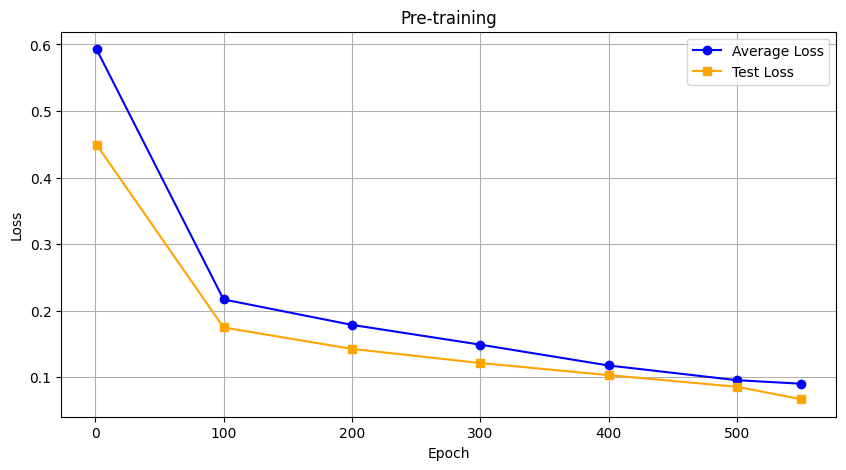

In [ ]:
import re
import matplotlib.pyplot as plt

from google.colab import output
cell_outputs = str(In)

log_data = """
Epoch 1/3200 : Average Loss 0.5928. Test Loss 0.4496
Epoch 100/3200 : Average Loss 0.2169. Test Loss 0.1748
Epoch 200/3200 : Average Loss 0.1787. Test Loss 0.1426
Epoch 300/3200 : Average Loss 0.1490. Test Loss 0.1214
Epoch 400/3200 : Average Loss 0.1177. Test Loss 0.1032
Epoch 500/3200 : Average Loss 0.0956. Test Loss 0.0857
Epoch 550/3200 : Average Loss 0.0903. Test Loss 0.0670
"""

epochs = [1, 100, 200, 300, 400, 500, 550]
train_loss = [0.5928, 0.2169, 0.1787, 0.1490, 0.1177, 0.0956, 0.0903]
test_loss = [0.4496, 0.1748, 0.1426, 0.1214, 0.1032, 0.0857, 0.0670]

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_loss, label='Average Loss', color='blue', marker='o')
plt.plot(epochs, test_loss, label='Test Loss', color='orange', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Pre-training')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
!mkdir -p embed

In [ ]:
import numpy as np

Zaktualizowanie data_config.json zgodnie z etykietami projektu

In [ ]:
import json

config_path = '/content/LIMU-BERT-Public/dataset/data_config.json'

with open(config_path) as f:
    config = json.load(f)

config['motion_20_120'] = {
    "sr": 20,
    "seq_len": 120,
    "dimension": 6,
    "activity_label_index": 0,
    "activity_label_size": 6,
    "activity_label": ["jumping_jacks", "pushups", "sitting", "squats", "standing", "walking"],
    "user_label_index": 0,
    "user_label_size": 1,
    "model_label_index": 0,
    "model_label_size": 1,
    "size": 744
}

with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)

print("Zaktualizowano:")
print(json.dumps(config['motion_20_120'], indent=2))

Zaktualizowano:
{
  "sr": 20,
  "seq_len": 120,
  "dimension": 6,
  "activity_label_index": 0,
  "activity_label_size": 6,
  "activity_label": [
    "jumping_jacks",
    "pushups",
    "sitting",
    "squats",
    "standing",
    "walking"
  ],
  "user_label_index": 0,
  "user_label_size": 1,
  "model_label_index": 0,
  "model_label_size": 1,
  "size": 744
}


Uruchomienie klasyfikatora

In [ ]:
%cd /content/LIMU-BERT-Public
!python embedding.py v1 motion 20_120 -f model
!python classifier.py v1 motion 20_120 -f model -l 0

/content/LIMU-BERT-Public
cuda:0 (1 GPUs)
Loading the model from saved/pretrain_base_motion_20_120/model
Train Size: 3168, Vali Size: 318, Test Size: 978
Balance Label Size: 30, Unlabel Size: 3138; Real Label Rate: 0.009
cuda:0 (1 GPUs)
Epoch 1/700 : Average Loss 1.7890, Accuracy: 0.167/0.000/0.000, F1: 0.084/0.000/0.000
Epoch 2/700 : Average Loss 1.7631, Accuracy: 0.267/0.000/0.000, F1: 0.142/0.000/0.000
Epoch 3/700 : Average Loss 1.7375, Accuracy: 0.300/0.000/0.000, F1: 0.160/0.000/0.000
Epoch 4/700 : Average Loss 1.7123, Accuracy: 0.300/0.000/0.000, F1: 0.160/0.000/0.000
Epoch 5/700 : Average Loss 1.6874, Accuracy: 0.300/0.000/0.000, F1: 0.156/0.000/0.000
Epoch 6/700 : Average Loss 1.6630, Accuracy: 0.300/0.000/0.000, F1: 0.150/0.000/0.000
Epoch 7/700 : Average Loss 1.6391, Accuracy: 0.300/0.019/0.000, F1: 0.150/0.013/0.000
Epoch 8/700 : Average Loss 1.6157, Accuracy: 0.300/0.057/0.000, F1: 0.150/0.036/0.000
Epoch 9/700 : Average Loss 1.5929, Accuracy: 0.367/0.075/0.000, F1: 0.239/0

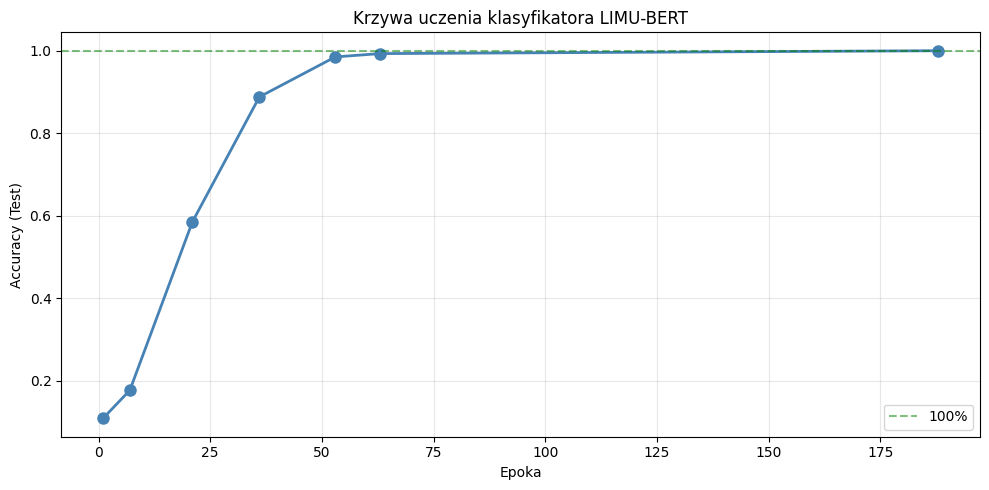

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

epochs = list(range(1, 701))
test_acc = [0.109, 0.110, 0.110, 0.110, 0.110, 0.110, 0.177, 0.191,
            0.199, 0.207]

key_epochs  = [1, 7, 21, 36, 53, 63, 188]
key_acc     = [0.109, 0.177, 0.585, 0.888, 0.985, 0.993, 1.000]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(key_epochs, key_acc, 'o-', color='steelblue', linewidth=2, markersize=8)
ax.axhline(y=1.0, color='green', linestyle='--', alpha=0.5, label='100%')
ax.set_xlabel('Epoka')
ax.set_ylabel('Accuracy (Test)')
ax.set_title('Krzywa uczenia klasyfikatora LIMU-BERT')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Eksportowanie gotowego modelu

In [ ]:
import shutil, os, torch

os.makedirs('/content/limu_export', exist_ok=True)

shutil.copy('/content/label_encoder.pkl', '/content/limu_export/')

shutil.copytree('saved/classifier_base_gru_motion_20_120',
                '/content/limu_export/classifier_base_gru_motion_20_120',
                dirs_exist_ok=True)


shutil.copytree('saved/pretrain_base_motion_20_120',
                '/content/limu_export/pretrain_base_motion_20_120',
                dirs_exist_ok=True)

shutil.make_archive('/content/limu_model', 'zip', '/content/limu_export')

'/content/limu_model.zip'

In [ ]:
import numpy as np

data   = np.load('/content/LIMU-BERT-Public/dataset/motion/data_20_120.npy')
labels = np.load('/content/LIMU-BERT-Public/dataset/motion/label_20_120.npy')
labels_flat = labels[:, 0, 0]

# Pokaż średnie wartości dla każdej klasy
names = ['jumping_jacks', 'pushups', 'sitting', 'squats', 'standing', 'walking']

for cls_id, name in enumerate(names):
    idx = np.where(labels_flat == cls_id)[0]
    d = data[idx]
    print(f"{name:15s} ax={d[:,:,0].mean():6.2f} ay={d[:,:,1].mean():6.2f} az={d[:,:,2].mean():6.2f} "
          f"gx={d[:,:,3].mean():6.2f} gy={d[:,:,4].mean():6.2f} gz={d[:,:,5].mean():6.2f}")

jumping_jacks   ax= -0.09 ay= -0.09 az=  0.34 gx=  0.17 gy= -0.05 gz=  0.02
pushups         ax=  1.65 ay=  1.11 az= -1.40 gx=  0.14 gy= -0.08 gz=  0.02
sitting         ax= -1.27 ay=  1.45 az=  1.24 gx=  0.14 gy= -0.08 gz=  0.02
squats          ax= -0.53 ay=  0.47 az=  0.39 gx=  0.17 gy= -0.06 gz=  0.03
standing        ax=  0.26 ay= -0.14 az= -0.22 gx=  0.14 gy= -0.08 gz=  0.02
walking         ax=  0.05 ay= -0.27 az= -0.12 gx= -0.14 gy=  0.06 gz= -0.02


In [ ]:
import glob
import pandas as pd
import numpy as np

files = glob.glob('/limu-bert-data/*.csv')

for f in sorted(files):
    df = pd.read_csv(f)
    label = df['label'].iloc[0]
    print(f"{label:15s} ax={df['acc_x'].mean():6.2f} ay={df['acc_y'].mean():6.2f} az={df['acc_z'].mean():6.2f} "
          f"gx={df['gyro_x'].mean():6.2f} gy={df['gyro_y'].mean():6.2f} gz={df['gyro_z'].mean():6.2f}  →  {f.split('/')[-1]}")

jumping_jacks   ax= -0.02 ay= -1.00 az=  0.19 gx=  1.40 gy=  0.06 gz= -0.80  →  jumping_jacks_20260607_215611.csv
jumping_jacks   ax= -0.00 ay= -0.99 az=  0.23 gx=  1.27 gy=  0.17 gz= -0.68  →  jumping_jacks_20260607_215916.csv
jumping_jacks   ax= -0.06 ay= -0.98 az=  0.24 gx=  0.66 gy=  1.11 gz= -0.60  →  jumping_jacks_20260608_151853.csv
jumping_jacks   ax= -0.00 ay= -1.00 az=  0.19 gx=  0.23 gy=  0.89 gz= -0.34  →  jumping_jacks_20260608_180504.csv
pushups         ax=  1.01 ay= -0.21 az= -0.43 gx= -0.15 gy= -0.14 gz= -0.23  →  pushups_20260607_212824.csv
pushups         ax=  1.00 ay= -0.21 az= -0.43 gx= -0.09 gy= -0.00 gz= -0.26  →  pushups_20260608_140122.csv
pushups         ax=  1.01 ay= -0.24 az= -0.39 gx= -0.16 gy= -0.01 gz= -0.31  →  pushups_20260608_152751.csv
pushups         ax=  1.00 ay= -0.23 az= -0.42 gx= -0.05 gy= -0.07 gz= -0.35  →  pushups_20260608_153126.csv
sitting         ax= -0.72 ay= -0.01 az=  0.54 gx= -0.12 gy=  0.23 gz= -0.05  →  sitting_20260608_175249.csv
sitt

In [ ]:
import os

# Szukaj wszystkich plików npy
for root, dirs, files in os.walk('/content'):
    for f in files:
        if f.endswith('.npy'):
            path = os.path.join(root, f)
            size = os.path.getsize(path)
            print(f"{size:10d} bytes  {path}")

       176 bytes  /content/mean.npy
       176 bytes  /content/std.npy
       176 bytes  /content/limu_export/mean.npy
       176 bytes  /content/limu_export/std.npy
   4009088 bytes  /content/LIMU-BERT-Public/dataset/uci/label_20_120.npy
  12027008 bytes  /content/LIMU-BERT-Public/dataset/uci/data_20_120.npy
  30240128 bytes  /content/LIMU-BERT-Public/dataset/shoaib/label_20_120.npy
  45360128 bytes  /content/LIMU-BERT-Public/dataset/shoaib/data_20_120.npy
      6080 bytes  /content/LIMU-BERT-Public/dataset/motion/groups_20_120.npy
    714368 bytes  /content/LIMU-BERT-Public/dataset/motion/label_20_120.npy
   4285568 bytes  /content/LIMU-BERT-Public/dataset/motion/data_20_120.npy
  26398208 bytes  /content/LIMU-BERT-Public/dataset/hhar/label_20_120.npy
  52796288 bytes  /content/LIMU-BERT-Public/dataset/hhar/data_20_120.npy
  25712768 bytes  /content/LIMU-BERT-Public/embed/embed_model_motion_20_120.npy


In [ ]:
files = glob.glob('/limu-bert-data/squats*.csv')
for f in sorted(files):
    df = pd.read_csv(f)
    print(f"{f.split('/')[-1]}: acc_x={df['acc_x'].mean():.2f} acc_z={df['acc_z'].mean():.2f} gyro_std={df[['gyro_x','gyro_y','gyro_z']].std().mean():.2f}")

squats_20260608_150511.csv: acc_x=-0.30 acc_z=0.20 gyro_std=46.90
squats_20260608_151121.csv: acc_x=-0.30 acc_z=0.20 gyro_std=47.33
squats_20260608_173358.csv: acc_x=-0.26 acc_z=0.23 gyro_std=52.20
squats_20260608_174031.csv: acc_x=-0.29 acc_z=0.28 gyro_std=57.32
